# Predicting Student Academic Success (Pass / Fail)
### CPE393 – Introduction to Data Science with Python | Final Group Project
**Dataset:** UCI / Kaggle "Student Performance" data set (Math course), `studentmat.csv`

## 1. Problem Definition and Goals



**Our problem statement:**
Schools want to identify, as early as possible, which students are at risk of failing a course so
that teachers can offer extra support before it is too late. We will treat this as a **binary
classification problem**: given information about a student (demographics, family background, study
habits, school support, social life), predict whether the student's final grade (`G3`) corresponds to
a **pass** or a **fail**.

- **Target variable:** a new binary column `pass`, derived from `G3` (final grade, 0–20 scale).
  We use the standard rule from the Portuguese grading system: `G3 >= 10` → pass (1), otherwise fail (0).
- **Why it matters:** if school-related and behavioural features (absences, study time, past
  failures, family support) can predict pass/fail reasonably well, schools could use similar models
  to flag at-risk students for tutoring, *without* needing to wait for the final exam.
- **Type of ML task:** supervised learning → binary classification.
- **Models we will compare:** Logistic Regression, Decision Tree, Random Forest (as proposed).


## 2. Import Libraries

- `pandas`: loads tabular data into a **DataFrame** (a table with labeled rows/columns) and gives us
  tools to filter, group, and transform it.
- `numpy`: fast numerical arrays and math operations; pandas is built on top of it.
- `matplotlib.pyplot` / `seaborn`: plotting. Matplotlib is the low-level engine; Seaborn is a
  higher-level wrapper that makes statistical plots (histograms, boxplots, heatmaps) easier and
  nicer-looking.
- `sklearn` (scikit-learn): the standard Python machine learning library. It gives us a consistent
  API (`.fit()`, `.predict()`) for preprocessing, models, and evaluation metrics.
- `random_state` / a fixed **seed**: Setting a fixed seed makes results **reproducible** — anyone re-running this notebook
  gets the exact same numbers.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## 3. Dataset Description


- **Source:** UCI Machine Learning Repository / Kaggle mirror, "Student Performance Data Set"
  (P. Cortez, Univ. Minho, 2008), Math class subset (`student-mat.csv`, here `studentmat.csv`).
- **License:** publicly available for research/education use; original paper: Cortez & Silva (2008),
  "Using Data Mining to Predict Secondary School Student Performance."
- **Size:** 395 rows (students), 33 columns (32 features + `G3`, the final grade).


In [ ]:


from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/student-mat.csv",
    sep=","
)

print("Shape (rows, columns):", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape (rows, columns): (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

**Reading `df.info()`:** it tells us, per column, how many non-null values exist and the dtype
(`int64` = whole number, `object`/`string` = text/categorical).


## 4. Preprocessing and Cleaning
Our checklist of cleaning the data :
1. Missing values
2. Duplicate rows
3. Incorrect / inconsistent data types
4. Outliers
5. Unnecessary columns



In [1]:

print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")
df.isnull().sum()[df.isnull().sum() > 0]   # will be empty if there is no missing data


Missing values per column:


NameError: name 'df' is not defined

In [ ]:
# verifie Duplicate rows
print("Numbr of exact duplicate rows:", df.duplicated().sum())


Number of exact duplicate rows: 0


In [ ]:
# Data types
df.dtypes


,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


**Decision:** all numeric columns (age, grades, study time, etc.) are already stored as integers.
 All categorical columns (school, sex, Mjob, reason, etc.) are stored as text/object.


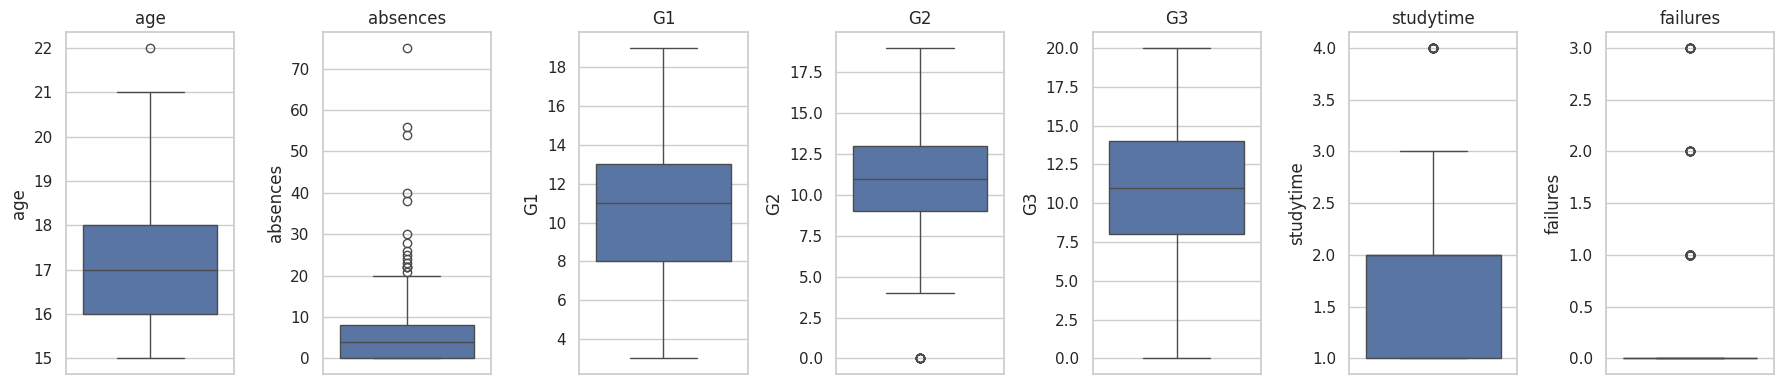

In [ ]:
# Outlier check on key numeric columns using boxplots
num_check = ["age", "absences", "G1", "G2", "G3", "studytime", "failures"]
fig, axes = plt.subplots(1, len(num_check), figsize=(18, 4))
for ax, col in zip(axes, num_check):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretation:** `absences` has a right-skewed tail — a handful of students have far more
absences (20+) than the rest. `G3` shows a few zeros, which in this dataset represent students who
did not sit the final exam rather than a measurement error.

**Decision:** we keep these points. They are **valid, real values**, not data-entry mistakes
(no negative ages, no grades above 20, no negative absences), so removing them would throw away
genuine information about at-risk students — exactly the group this project cares about. Concept
note: an outlier should only be removed when it is implausible or a known data error, not simply
because it is extreme.


## 5. Exploratory Data Analysis (EDA) and Data Visualization

Before modeling, we look at distributions, relationships, and trends to build
intuition and to catch anything cleaning missed. Every chart below has a title, axis labels, and a
short interpretation, as required.


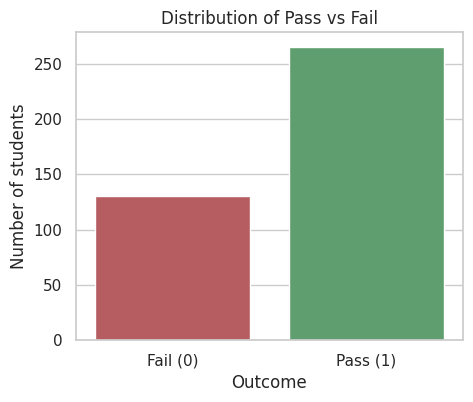

pass
1    0.671
0    0.329
Name: proportion, dtype: float64


In [ ]:
df["pass"] = (df["G3"] >= 10).astype(int)

plt.figure(figsize=(5, 4))
sns.countplot(x="pass", hue="pass", data=df, palette=["#C44E52", "#55A868"], legend=False)
plt.xticks([0, 1], ["Fail (0)", "Pass (1)"])
plt.title("Distribution of Pass vs Fail")
plt.xlabel("Outcome")
plt.ylabel("Number of students")
plt.show()

print(df["pass"].value_counts(normalize=True).round(3))


**Interpretation:** about 67% of students pass and 33% fail — a moderate **class imbalance**
(not extreme, but worth noting). Concept: when classes are imbalanced, **accuracy alone can be
misleading** (a model that always predicts "pass" would already score ~67% accuracy without learning
anything). This is exactly why the rubric also asks for precision, recall, and F1-score — they expose
that kind of lazy model.


In [2]:

df.describe()


NameError: name 'df' is not defined

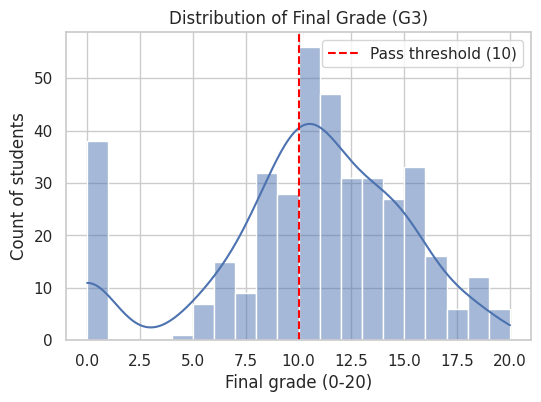

In [ ]:

plt.figure(figsize=(6, 4))
sns.histplot(df["G3"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final grade (0-20)")
plt.ylabel("Count of students")
plt.axvline(10, color="red", linestyle="--", label="Pass threshold (10)")
plt.legend()
plt.show()


**Interpretation:** grades are roughly bell-shaped but with a spike of zeros (students who did
not take the final exam) and a cluster right around the pass boundary — meaning many students are
"close calls," which is exactly the group a support program would want to identify.


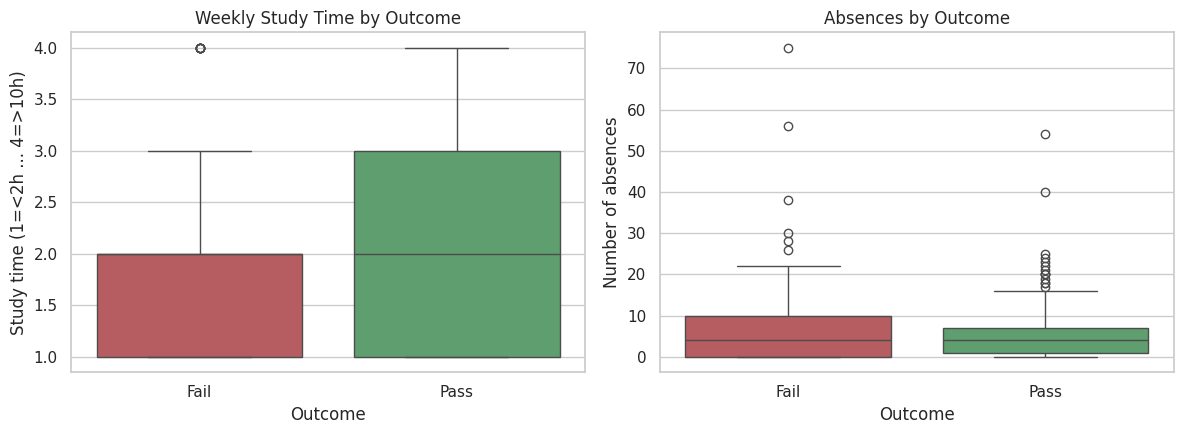

In [ ]:
#Study time and absences vs outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(x="pass", y="studytime", hue="pass", data=df, ax=axes[0], palette=["#C44E52", "#55A868"], legend=False)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Fail", "Pass"])
axes[0].set_title("Weekly Study Time by Outcome")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Study time (1=<2h ... 4=>10h)")

sns.boxplot(x="pass", y="absences", hue="pass", data=df, ax=axes[1], palette=["#C44E52", "#55A868"], legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Fail", "Pass"])
axes[1].set_title("Absences by Outcome")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Number of absences")

plt.tight_layout()
plt.show()


**Interpretation:** students who pass tend to report slightly higher study time on median, and
the failing group shows a slightly wider spread of absences. The relationship is real but **not
dramatic** on its own — a reminder that no single feature perfectly predicts the outcome, which is
exactly why we need a model that can combine many features.


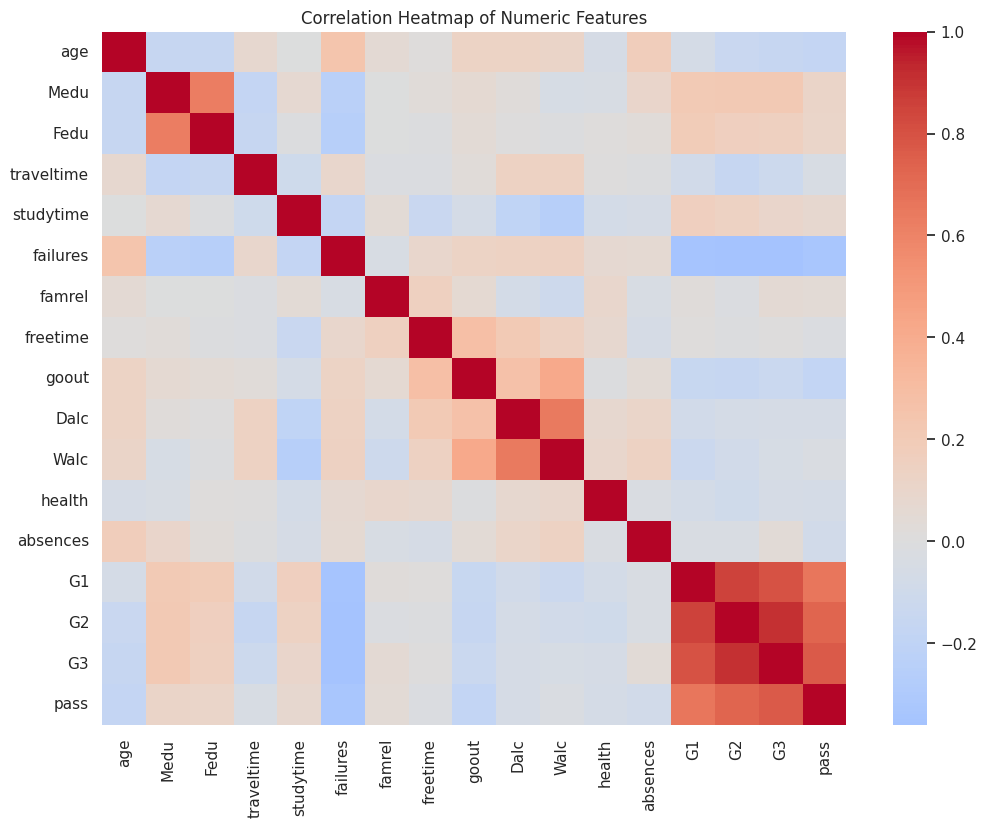

,G3
G3,1.000000
G2,0.904868
G1,0.801468
pass,0.770042
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307


In [ ]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

numeric_df.corr()["G3"].sort_values(ascending=False)


**Interpretation — concept, correlation:** correlation measures how strongly two numeric
variables move together, from -1 (perfectly opposite) to +1 (perfectly together). `G1` and `G2`
(first- and second-period grades) are, unsurprisingly, very strongly correlated with `G3` (they are
earlier measurements of the same thing). `failures` (past class failures) is negatively correlated
with `G3`. This is an important early warning sign we will return to formally in Section 8
(data leakage), because `G1`/`G2` are *so* predictive that including them changes what our model is
actually measuring.


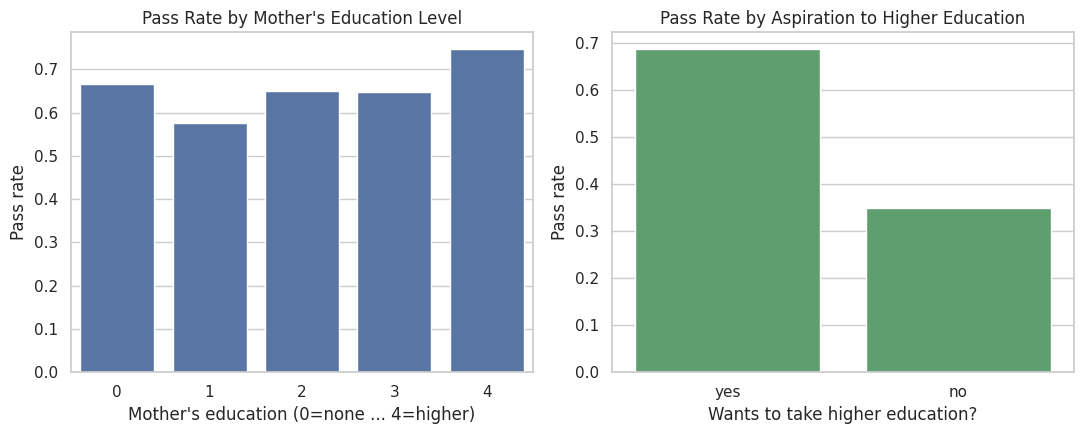

In [ ]:
#Categorical feature vs outcome: parents' education
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(x="Medu", y="pass", data=df, ax=axes[0], color="#4C72B0", errorbar=None)
axes[0].set_title("Pass Rate by Mother's Education Level")
axes[0].set_xlabel("Mother's education (0=none ... 4=higher)")
axes[0].set_ylabel("Pass rate")

sns.barplot(x="higher", y="pass", data=df, ax=axes[1], color="#55A868", errorbar=None)
axes[1].set_title("Pass Rate by Aspiration to Higher Education")
axes[1].set_xlabel("Wants to take higher education?")
axes[1].set_ylabel("Pass rate")
plt.tight_layout()
plt.show()


**Interpretation:** pass rate tends to rise with mother's education level, and students who say
they want to pursue higher education pass at a noticeably higher rate than those who don't. Both are
plausible proxies for motivation and home support — good candidate features for modeling.


## 6. Feature Engineering

Transforming raw columns into a form a model can use well, and
optionally creating new columns that carry useful signal.

Steps here:
1. **Create the target variable** `pass` from `G3`
2. **Encode categorical variables** — models need numbers, not text.
   - *Binary categories mapped to 0/1.
   - *Multi-category nominal columns*  **one-hot encoding** (`pd.get_dummies`): each category becomes its own 0/1
     column. This avoids falsely telling the model that, say, "teacher" > "health" > "at_home" on some
     numeric scale, which plain integer-coding would imply.
3. **Feature scaling**: Logistic Regression is sensitive to the *scale* of numeric features because it computes weighted sums; without scaling,
   large-range features can dominate purely due to units, not importance. We apply
   **StandardScaler** do not need
   scaling — they split on thresholds, not weighted sums — but scaling does not hurt them either, so
   we apply it consistently for a fair, simple pipeline.
4. We deliberately **exclude `G1` and `G2`** from the main feature set (explained in Section 8) and
   build a separate comparison model that includes them, purely to demonstrate the concept of
   leakage-like inflation.


In [ ]:
df_enc = df.copy()

binary_cols = ["school", "sex", "address", "famsize", "Pstatus", "schoolsup", "famsup", "paid",
               "activities", "nursery", "higher", "internet", "romantic"]
nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]

df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)

for c in binary_cols:
    df_enc[c] = df_enc[c].astype("category").cat.codes

print("Encoded shape:", df_enc.shape)
df_enc.head()


Encoded shape: (395, 43)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,...,Walc,health,absences,G1,G2,G3,pass,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,0,1,0,0,0,1,1,0,0,4,...,1,3,6,5,6,6,0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,0,0,17,1,0,1,1,1,1,2,0,0,1,0,0,0,1,1,0,5,...,1,3,4,5,5,6,0,False,False,False,False,False,True,False,False,False,False,False,False,False
2,0,0,15,1,1,1,1,1,1,2,3,1,0,1,0,1,1,1,0,4,...,3,3,10,7,8,10,1,False,False,False,False,False,True,False,False,False,True,False,True,False
3,0,0,15,1,0,1,4,2,1,3,0,0,1,1,1,1,1,1,1,3,...,1,5,2,15,14,15,1,True,False,False,False,False,False,True,False,True,False,False,True,False
4,0,0,16,1,0,1,3,3,1,2,0,0,1,1,0,1,1,0,0,4,...,2,5,4,6,10,10,1,False,True,False,False,False,True,False,False,True,False,False,False,False


In [ ]:
# Main feature set: (exclude G1, G2)
drop_cols = ["G3", "G1", "G2", "pass"]
X = df_enc.drop(columns=drop_cols)
y = df_enc["pass"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Feature matrix shape: (395, 39)
Target distribution:
 pass
1    265
0    130
Name: count, dtype: int64


## 7. Train-Test Split

if we train and evaluate on the same rows, the model can simply
"memorize" the data (this is called **overfitting**), giving a falsely optimistic score. Instead we
hold out a portion of the data (the **test set**) that the model never sees during training, and use
it only at the very end to check how well the model generalizes to new students.

- `test_size=0.2` → 20% of students held out for testing, 80% used for training.
- `random_state=42` → fixes the random shuffling so the split is identical every time we re-run the
  notebook (**reproducibility**, required by the assignment).
- `stratify=y` → keeps the same pass/fail ratio (~67/33) in both the train and test sets. Without
  this, random chance could give the test set an unusually different class balance, especially with
  only 395 rows.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train size: (316, 39)  Test size: (79, 39)
Train class balance:
 pass
1    0.671
0    0.329
Name: proportion, dtype: float64
Test class balance:
 pass
1    0.671
0    0.329
Name: proportion, dtype: float64


In [ ]:

num_cols = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel",
            "freetime", "goout", "Dalc", "Walc", "health", "absences"]

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])


## 8. Machine Learning Model Training

The three algorithms of ML:

- **Logistic Regression** (`max_iter=1000`): a linear model — it learns one weight per feature and
  combines them into a probability via the sigmoid function. `max_iter` is raised from scikit-learn's
  default of 100 because with 39 features the default sometimes stops before the optimizer actually
  converges; this doesn't change the model, it just gives it enough iterations to finish properly.
- **Decision Tree** (`max_depth=5`): learns a sequence of yes/no splits on feature values. Left
  unrestricted, a tree can grow one leaf per training row and simply memorize the training set
  (**overfitting**) — capping the depth forces it to generalize instead of memorize.
- **Random Forest** (`n_estimators=200, max_depth=6`): trains 200 individual decision trees, each on
  a random subset of rows and features, and averages their votes. This "wisdom of the crowd" approach
  is usually more stable than any single tree.




In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    trained_models[name] = model
print("All three models trained.")


All three models trained.


## 9. Evaluation Metrics and Results

Our classes are imbalanced (~67% pass /
33% fail — see the EDA section), so a model that always predicts "pass" would already score ~67%
accuracy while learning nothing. That's why we report:

- **Accuracy** — overall fraction correct (can be misleading alone, as above).
- **Precision** — of students predicted to pass, what fraction actually passed.
- **Recall** — of students who actually passed, what fraction did we correctly catch? (For this
  project, recall on the **fail** class specifically is the more operationally important number,
  since the whole point is catching at-risk students — see the classification reports below.)
- **F1-score** — harmonic mean of precision and recall, a single balanced number.


In [ ]:
results = []
for name, model in trained_models.items():
    pred = model.predict(X_test_s)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.658,0.717,0.811,0.761
Decision Tree,0.684,0.719,0.868,0.786
Random Forest,0.658,0.691,0.887,0.777


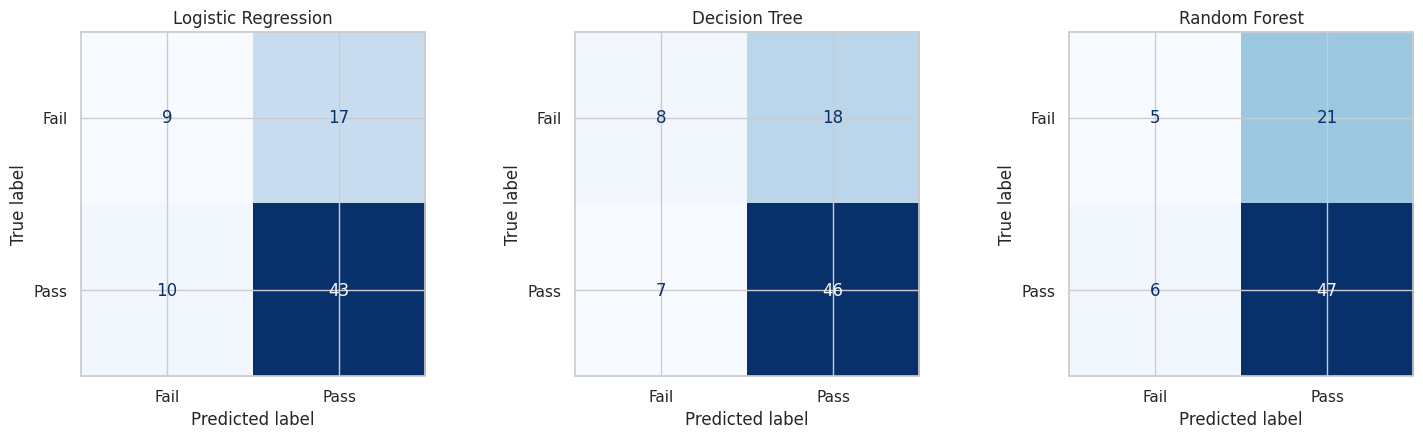

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, model) in zip(axes, trained_models.items()):
    pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Fail", "Pass"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


**Interpretation:** all three models land in a similar range (roughly 66–68% accuracy,
~76–79% F1 on the majority "pass" class), noticeably better than the ~67% a model would get by
blindly predicting "pass" for everyone, but far from perfect. Recall on the **fail** class (the
harder, more important class here) is the metric to watch when comparing models for this specific
use case — check the confusion matrices above: the top-left cell (Fail correctly predicted as Fail)
is what a school counselor would care about most.


## 10. Feature Importance (Random Forest)

Random Forest can report how much each feature reduced impurity
(mixed pass/fail groups) across all its trees, on average. This gives a ranked view of which features
the model actually relied on — useful both for interpretation and for double-checking that the model
is learning something sensible rather than a data artifact.


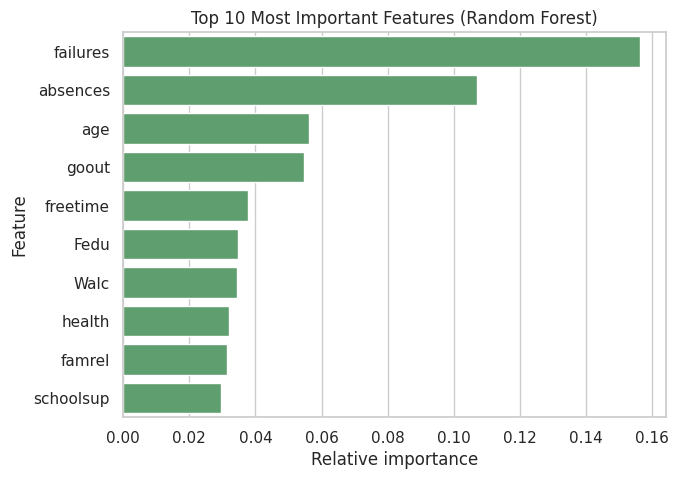

In [ ]:
importances = pd.Series(trained_models["Random Forest"].feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x=top_features.values, y=top_features.index, color="#55A868")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Relative importance")
plt.ylabel("Feature")
plt.show()


**Interpretation:** features like `absences`, `failures`, `age`, and `goout` (going out with
friends) typically rank highly — all plausible, human-understandable drivers of academic outcome.
This is a useful sanity check: the model is not relying on something nonsensical.


## 11. Data Leakage Case Study: Adding G1 and G2

Leakage happens when a model has access, directly or indirectly, to
information it would not realistically have at prediction time, making performance look artificially
good. `G1` and `G2` are grades from *earlier in the same course* — including them is not the classic
"used the test set during training" leakage, but it is a closely related problem sometimes called
**target leakage**: `G1`/`G2` are so strongly correlated with `G3` that a model using
them is mostly just restating a grade the student already has, not learning general risk factors from
behaviour and background. Whether this is "acceptable" depends entirely on the real-world use case:
if the goal is *early-in-the-year* prediction using only background/behavioural data, G1/G2 should be
excluded. If the goal is a *mid-year check-in* after G2 exists, including
them is legitimate. We show both, honestly, side by side.


In [ ]:
X_leak = df_enc.drop(columns=["G3", "pass"])   # now includes G1, G2
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leak, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

num_cols_leak = num_cols + ["G1", "G2"]
scaler_leak = StandardScaler()
Xl_train_s = Xl_train.copy(); Xl_test_s = Xl_test.copy()
Xl_train_s[num_cols_leak] = scaler_leak.fit_transform(Xl_train[num_cols_leak])
Xl_test_s[num_cols_leak] = scaler_leak.transform(Xl_test[num_cols_leak])

leak_results = []
for name, model in models.items():
    m = model.__class__(**model.get_params())
    m.fit(Xl_train_s, yl_train)
    pred = m.predict(Xl_test_s)
    leak_results.append({"Model": name, "Accuracy (with G1,G2)": accuracy_score(yl_test, pred),
                          "F1 (with G1,G2)": f1_score(yl_test, pred)})

comparison = results_df[["Accuracy", "F1-score"]].join(
    pd.DataFrame(leak_results).set_index("Model")
)
comparison.round(3)


,Accuracy,F1-score,"Accuracy (with G1,G2)","F1 (with G1,G2)"
Model,,,,
Logistic Regression,0.658,0.761,0.886,0.911
Decision Tree,0.684,0.786,0.848,0.875
Random Forest,0.658,0.777,0.873,0.900


**Interpretation:** accuracy jumps from roughly ~66–68% to ~85–89% once `G1`/`G2` are added.
This is a dramatic, concrete illustration of why the assignment's Responsible AI checklist asks
students to "avoid data leakage" and to "report limitations honestly": a headline number like "89%
accuracy!" would be misleading here unless we clearly state *which* feature set produced it, and
whether that feature set matches how the model would actually be used in practice.


## 13. Conclusion and Future Work

**Main findings:**
- Using only background and behavioural features (no in-course grades), all three models predict
  pass/fail at roughly 66–68% accuracy and ~76–79% F1 on the pass class — clearly better than a
  naive always-"pass" baseline, but with real room for error, meaning this model should support,
  not replace, teacher judgement.
- `absences`, `failures`, `goout`, and `age` are consistently among the most influential features.
- Including `G1`/`G2` sharply raises apparent performance, illustrating a leakage-style risk that
  must be disclosed rather than hidden.

**Limitations:**
- Small dataset (395 students, one subject, two schools, one region/era) limits how far these
  findings generalize.
- Several features are self-reported survey answers, which can carry reporting bias.
- No external validation on a different school/year was possible.

**Future work:**
- Try additional models (e.g. gradient boosting) and cross-validation instead of a single split to
  get more stable estimates given the small sample size.
- Explore the Portuguese-language-course dataset (`student-por.csv`) for a larger sample or a
  combined analysis.
- Investigate fairness metrics across subgroups (e.g. by `address` or `sex`) before considering any
  real deployment.

